In [2]:
import numpy as np 
import pandas as pd
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 250) 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))       


In [4]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_score, recall_score, f1_score, RocCurveDisplay
from fastai.tabular.all import *

In [5]:
df = pd.read_parquet('./Downloads/KronoDroid/kronodroid-2021-emu-v1.parquet')


In [6]:
df.head()

,Package,Malware,getuid32,getgid32,geteuid32,getegid32,getgroups32,getppid,kill,tgkill,ptrace,getpriority,setpriority,ugetrlimit,setrlimit,prctl,sigaltstack,read,write,pread64,pwrite64,close,getpid,munmap,mremap,...,normal,dangerous,signature,custom_yes,nr_custom,total_perm,sha256,CFileSize,UFileSize,FirstModDate,LastModDate,FilesInsideAPK,TimesSubmitted,Activities,NrIntServices,NrIntServicesActions,NrIntActivities,NrIntActivitiesActions,NrIntReceivers,NrIntReceiversActions,TotalIntentFilters,NrServices,Scanners,Detection_Ratio,MalFamily
0,jp.hamachi.android.apsalus\n,0,74,0,3,0,0,0,0,0,0,0,0,1,0,37,0,198,121,159,28,70,0,113,0,...,0,1,0,0,0,1,971c40bc57539e35eaa4e39440ddbf60e2d86745d8b28a73ca6170c7ade8c706,231168,400992,7/27/2011,7/27/2011,79.0,7,14.0,0.0,0.0,2.0,2.0,0.0,0.0,2.0,0.0,66,0.000000,
1,org.wikipedia\n,0,230,0,0,0,0,0,0,0,0,0,0,0,0,35,0,11,32,163,0,45,0,96,0,...,5,2,0,1,3,10,82a0062a3dde0bd09c284dde1d9817b79e75b98f9288b51b573b9807bb1c803c,9781011,10687306,1/1/1980,1/19/2020,1396.0,5,32.0,2.0,2.0,4.0,5.0,2.0,6.0,10.0,3.0,61,0.000000,
2,fr.kwiatkowski.ApkTrack\n,0,100,0,0,0,0,0,0,0,0,0,0,0,0,27,0,9,32,99,0,21,0,47,0,...,4,1,1,0,0,6,8b555fb2de468eb9074a7b7464fa61a5d52f9e9b331120243112078ab429c006,2481494,5522255,1/1/1980,9/16/2017,533.0,15,2.0,0.0,0.0,1.0,3.0,0.0,4.0,4.0,3.0,66,0.000000,
3,com.mobisystems.msdict.embedded.wireless.pons.kompaktit\n,0,113,0,0,0,0,0,0,0,0,0,0,1,0,56,0,1149,640,205,0,112,0,187,0,...,2,2,0,0,0,4,077f0f9717a8820ff532b1e3e4039eca64a038aaed1eb1a325faac7cbd3c5a6e,635696,1129936,6/14/2011,6/14/2011,84.0,5,8.0,0.0,0.0,3.0,3.0,0.0,2.0,5.0,1.0,65,0.000000,
4,appinventor.ai_jmonfu.Hamrun3\n,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,0,0,0,5,0,...,2,0,0,0,0,2,b5d6dab5a57f24b07ce4a810b1332bd51d2724373e2392badbf3391082a514c1,4086455,5593090,6/8/2011,6/8/2011,11.0,9,3.0,0.0,0.0,2.0,2.0,0.0,0.0,2.0,0.0,65,0.046154,FakeInst


In [10]:
df.tail()

,Package,Malware,getuid32,getgid32,geteuid32,getegid32,getgroups32,getppid,kill,tgkill,ptrace,getpriority,setpriority,ugetrlimit,setrlimit,prctl,sigaltstack,read,write,pread64,pwrite64,close,getpid,munmap,mremap,...,normal,dangerous,signature,custom_yes,nr_custom,total_perm,sha256,CFileSize,UFileSize,FirstModDate,LastModDate,FilesInsideAPK,TimesSubmitted,Activities,NrIntServices,NrIntServicesActions,NrIntActivities,NrIntActivitiesActions,NrIntReceivers,NrIntReceiversActions,TotalIntentFilters,NrServices,Scanners,Detection_Ratio,MalFamily
63676,org.benjemaa.main\n,1,622,0,0,0,0,0,0,0,0,2,0,4,2,255,1,363,279,109,0,118,0,161,0,...,5,4,0,0,0,9,e19f1ac45cafaa6eb1a226a49b6ec7f10d44031ae331534def08d99a6a95552f,908490,1027922,2/12/2012,8/28/2012,0.0,9,9.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,1.0,66,0.333333,Airpush/StopSMS
63677,tv.j38c98d2.x1cec2\n,1,594,0,0,0,0,0,0,0,0,2,0,4,2,226,1,83,97,67,0,75,0,129,0,...,4,2,0,1,1,7,15e5bf87fe854b3a1ecf0e8446cd39ceda429d6b6e7d78f2f78fbfea7eb5959c,13471001,14856682,2/24/2014,2/24/2014,0.0,35,9.0,0.0,0.0,1.0,1.0,0.0,8.0,3.0,1.0,65,0.461538,Ewind
63678,net.ipromgames.android_promqueen3011.build\n,1,659,0,0,0,0,0,0,0,0,2,0,4,2,220,1,114,106,51,0,64,0,119,0,...,2,3,0,0,0,5,9dd759522050417825cf588b1ec7088b799e874ee25cf3f644fb39245c3c0dd2,390092,1091498,1/1/1980,3/3/2018,0.0,5,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,66,0.484848,FakeInst
63679,com.exae.zghxb.answers\n,1,44,0,0,0,0,0,0,0,0,0,0,1,0,86,0,144,102,116,0,63,0,135,0,...,4,3,1,0,0,8,ff493d26ee8cac44eb07004911dd0a7923c00a8d012b597dd356d71dabf80281,2364685,2785047,11/23/2013,11/24/2013,0.0,25,3.0,0.0,0.0,1.0,1.0,0.0,4.0,2.0,2.0,66,0.409091,Dowgin
63680,com.bukuoryzaee.cintabutasangpenulismuda\n,1,1141,0,0,0,0,0,0,0,0,2,0,3,2,207,1,207,312,104,0,60,0,70,0,...,2,0,0,0,0,2,954bcefe0f942144ab47cd9e692474a6a0b8859f878f1aac964f18a91d0dcd8f,817613,1566073,8/6/2014,10/22/2014,0.0,9,2.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,65,0.323077,Airpush/StopSMS


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63681 entries, 0 to 63680
Columns: 297 entries, Package to MalFamily
dtypes: category(5), float32(11), int16(47), int32(30), int8(204)
memory usage: 33.1 MB


In [14]:
df.isnull().sum()

Package               0
Malware               0
getuid32              0
getgid32              0
geteuid32             0
                     ..
TotalIntentFilters    0
NrServices            0
Scanners              0
Detection_Ratio       0
MalFamily             0
Length: 297, dtype: int64

In [16]:
df.columns

Index(['Package', 'Malware', 'getuid32', 'getgid32', 'geteuid32', 'getegid32', 'getgroups32', 'getppid', 'kill', 'tgkill',
       ...
       'NrIntServicesActions', 'NrIntActivities', 'NrIntActivitiesActions', 'NrIntReceivers', 'NrIntReceiversActions', 'TotalIntentFilters', 'NrServices', 'Scanners', 'Detection_Ratio', 'MalFamily'],
      dtype='object', length=297)

In [18]:
df = df.drop(columns=["FilesInsideAPK", "Detection_Ratio", "MalFamily"]) #FilesInsideAPK was only a column for the benign samples


In [20]:
target = 'Malware'

In [22]:
conts, cats = cont_cat_split(df, dep_var=target)
len(conts), len(cats)

(84, 209)

In [24]:
df = TabularPandas(
    df=df, 
    procs=[Categorify, Normalize],
    cat_names=cats,
    cont_names=conts,
    y_block=CategoryBlock,
    y_names=target,
    splits =  TrainTestSplitter(test_size=0.8, random_state=None, stratify=df[target], shuffle=True)(range_of(df)),
    reduce_memory=True,
)

In [26]:
df

       Package  Malware  getuid32  getgid32  geteuid32  getegid32  getgroups32  getppid  kill  tgkill  ptrace  getpriority  setpriority  ugetrlimit  setrlimit     prctl  sigaltstack      read     write   pread64  pwrite64     close    getpid  \
15787     4186        0 -0.093019         1  -0.144780          1            1        1     1       1       1    -0.523993            1           2          1 -0.173208            1 -0.182691 -0.328479 -0.148060 -0.075389 -0.305870 -0.019704   
40733    41167        1  0.169811         1  -0.144780          1            1        1     1       1       1     1.044415            1           4          3  0.220554            2  0.032362  1.015710 -0.087473 -0.075389 -0.160386 -0.019704   
58308    29985        1 -0.094644         1  -0.144780          1            1        1     1       1       1    -0.523993            1           1          1 -0.224569            1 -0.184337 -0.331697 -0.090580 -0.075389 -0.308839 -0.019704   
27777    45983      

In [28]:
len(df.train), len(df.valid)                          # 20%-80% of the rows as requested


(12736, 50945)

In [30]:
dls = df.dataloaders(bs=64)


## Results

In [33]:
roc_auc_binary = RocAucBinary()
tl = tabular_learner(dls, metrics=[roc_auc_binary])

In [35]:
cbs = [
    TrackerCallback(monitor='valid_loss', comp=None, min_delta=0.0, reset_on_fit=True),
    EarlyStoppingCallback(monitor='valid_loss', comp=None, min_delta=0.0, patience=1, reset_on_fit=True)
]

tl.fit_one_cycle(10, cbs=cbs) 

epoch,train_loss,valid_loss,roc_auc_score,time
0,0.211943,0.572229,0.969721,01:33
1,0.056679,0.275513,0.985457,01:31
2,0.038935,0.243235,0.989670,01:34
3,0.015667,0.334007,0.987929,01:33


No improvement since epoch 2: early stopping


In [20]:
preds_train, ground_truth_train = tl.get_preds(ds_idx=0, dl=None)

In [21]:
preds_train

tensor([[9.9964e-01, 3.5712e-04],
        [9.8228e-01, 1.7718e-02],
        [9.9983e-01, 1.6564e-04],
        ...,
        [9.9786e-01, 2.1355e-03],
        [6.3505e-04, 9.9936e-01],
        [1.4566e-05, 9.9999e-01]])

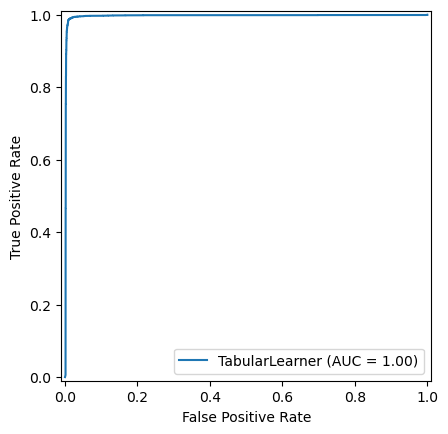

In [22]:
fpr, tpr, thresholds = roc_curve(to_np(ground_truth_train), to_np(preds_train[:,1]))
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='TabularLearner')
display.plot()

In [23]:
# Test set predictions
preds_test, ground_truth_test = tl.get_preds(ds_idx=1, dl=None) 

In [24]:
# transform tensor to numpy array
preds_test = to_np(preds_test[:,1]) 
ground_truth_test = to_np(ground_truth_test)

preds_test_binary = (preds_test >= best_thresh).astype(int)

print("Test predictions shape:", preds_test_binary.shape)
print("Best threshold:", best_thresh)

Test predictions shape: (50945,)
Best threshold: 0.21034503


In [25]:
print("The final tabular learner results")
print("ROC-AUC:", round(roc_auc_score(y_true=ground_truth_test, y_score=preds_test), 4))  
print("Precision:", round(precision_score(y_true=ground_truth_test, y_pred=preds_test_binary), 4))
print("Recall:", round(recall_score(y_true=ground_truth_test, y_pred=preds_test_binary), 4))
print("F1:", round(f1_score(y_true=ground_truth_test, y_pred=preds_test_binary), 4))

The final tabular learner results
ROC-AUC: 0.9873
Precision: 0.9629
Recall: 0.9478
F1: 0.9553
